<a href="https://colab.research.google.com/github/arjun15101989/ai-portfolio-risk-analyzer/blob/main/01_market_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing neccessary libraries

In [2]:
#Installing important libraries
!pip install -q yfinance pandas numpy pytest matplotlib plotly -q

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go


print("Libraries are succesfully installed and imported!")

Libraries are succesfully installed and imported!


# 2. Fetch Historical Data (NIFTY 50 & Top Equities)

In [5]:
#Define Indian Market Tickers

tickers ={
           "Nifty_50": "^NSEI",
           "Reliance" : "RELIANCE.NS",
           "TCS" : "TCS.NS",
           "Tata_Motors" : "TMCV.NS",
           "HDFC_Bank": "HDFCBANK.NS",
           "Tata_Steel" : "TATASTEEL.NS"
         }

# Pull Historical Data
data = yf.download(list(tickers.values()), start="2025-01-01", end="2026-09-09") ['Close']

# Ensure index is clean datetime format and drop missing values
data.index = pd.to_datetime(data.index)
data = data.dropna()

# Rename columns using dictionary values mapping back to clean names
data.columns = [k for k, v in tickers.items() if v in data.columns]

# Rename Column names to friendly names
data.columns = tickers.keys()
print("Data Preview:")
print(data.tail())


/tmp/ipykernel_4508/2765632846.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), start="2025-01-01", end="2026-09-09") ['Close']
[*********************100%***********************]  6 of 6 completed


Data Preview:
              Nifty_50     Reliance         TCS  Tata_Motors   HDFC_Bank  \
Date                                                                       
2026-09-02  700.799988  1313.099976  183.850006  2348.000000  447.450012   
2026-09-03  706.650024  1302.500000  184.199997  2320.100098  460.350006   
2026-09-04  712.099976  1322.000000  188.789993  2304.000000  458.200012   
2026-09-07  710.500000  1309.500000  185.610001  2270.000000  459.649994   
2026-09-08  703.000000  1294.900024  184.149994  2255.500000  456.049988   

              Tata_Steel  
Date                      
2026-09-02  23914.449219  
2026-09-03  23873.449219  
2026-09-04  23897.699219  
2026-09-07  23779.150391  
2026-09-08  23635.099609  


#3. Compute Normalized Returns & Visualize

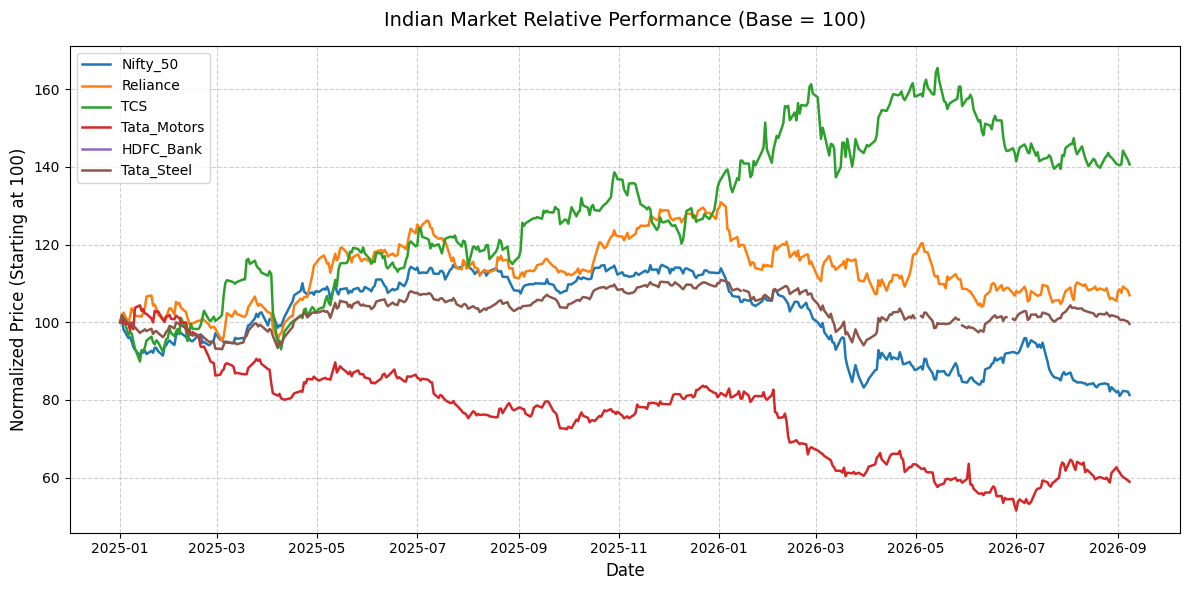

In [11]:
from matplotlib.lines import lineStyles
#1. Take every price column and divide it by its first available value (Day 1), then multiply by 100
normalized_data = (data/data.iloc[0]) * 100


# 2. Set up a plotting canvas (12 inches wide, 6 inches high)
plt.figure(figsize=( 12, 6))


# 3. Loop through each ticker column (NIFTY_50, Reliance, TCS, HDFC_Bank) and draw its line
for col in normalized_data.columns:
  plt.plot(normalized_data.index, normalized_data[col], label=col, linewidth=1.8)

#4. Add clear labels, a grid, and legend for scannability
plt.title("Indian Market Relative Performance (Base = 100)", fontsize=14, pad=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Starting at 100)", fontsize=12)
#plt.plot("Normalized Price")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout() # Fixes text overlap

#5. Show the plot
plt.show()
